In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
communication_matrix = pd.read_csv(
    "data/outputs/communication_matrix.csv",
    index_col=0
)

program_df = pd.read_csv(
    "data/outputs/communication_programs.csv"
)

print(communication_matrix.shape)
print(program_df.shape)

(138, 3489)
(3489, 2)


In [4]:
program_df["program"].value_counts().head(20)

program
87     1424
89      341
37      185
71      125
70      122
24       94
85       93
91       83
79       78
13       65
81       63
72       55
43       45
36       32
56       26
74       24
112      23
31       21
52       18
33       18
Name: count, dtype: int64

In [5]:
patient_programs = pd.DataFrame(index=communication_matrix.index)

for program in sorted(program_df["program"].unique()):

    features = program_df.loc[
        program_df["program"] == program,
        "feature"
    ]

    valid = [
        f for f in features
        if f in communication_matrix.columns
    ]

    patient_programs[f"Program_{program}"] = (
        communication_matrix[valid]
        .mean(axis=1)
    )

patient_programs.shape

(138, 144)

In [6]:
patient_programs.head()

,Program_1,Program_2,Program_3,Program_4,Program_5,Program_6,Program_7,Program_8,Program_9,Program_10,...,Program_135,Program_136,Program_137,Program_138,Program_139,Program_140,Program_141,Program_142,Program_143,Program_144
wu_natgen_CID3586,0.000007,0.0,0.0,0.0,0.0,0.000830,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
wu_natgen_CID3921,0.000000,0.0,0.0,0.0,0.0,0.001375,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
wu_natgen_CID45171,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
wu_natgen_CID3838,0.000000,0.0,0.0,0.0,0.0,0.003212,0.000108,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
wu_natgen_CID4066,0.000000,0.0,0.0,0.0,0.0,0.000719,0.000000,0.0,0.000118,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
patient_programs.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
Program_1,138.0,8.248985e-05,9.093496e-04,0.0,0.0,0.0,0.000000e+00,0.010683
Program_2,138.0,5.337116e-06,6.269691e-05,0.0,0.0,0.0,0.000000e+00,0.000737
Program_3,138.0,8.873613e-06,1.037230e-04,0.0,0.0,0.0,0.000000e+00,0.001219
Program_4,138.0,7.979288e-08,7.583361e-07,0.0,0.0,0.0,0.000000e+00,0.000009
Program_5,138.0,1.405717e-05,9.089734e-05,0.0,0.0,0.0,0.000000e+00,0.000925
Program_6,138.0,2.685628e-03,1.331048e-02,0.0,0.0,0.0,0.000000e+00,0.102885
Program_7,138.0,6.878119e-06,5.403638e-05,0.0,0.0,0.0,0.000000e+00,0.000577
Program_8,138.0,1.389727e-05,9.824734e-05,0.0,0.0,0.0,0.000000e+00,0.001091
Program_9,138.0,3.149719e-04,3.034097e-03,0.0,0.0,0.0,0.000000e+00,0.035492
Program_10,138.0,8.120535e-06,9.524570e-05,0.0,0.0,0.0,0.000000e+00,0.001119


In [8]:
program_var = patient_programs.var().sort_values(ascending=False)

program_var.head(20)

Program_24     2.193786
Program_85     1.594483
Program_87     0.410232
Program_93     0.326338
Program_91     0.291474
Program_26     0.253585
Program_81     0.248036
Program_105    0.105611
Program_72     0.062346
Program_96     0.054986
Program_92     0.037763
Program_77     0.028085
Program_111    0.024244
Program_90     0.021909
Program_99     0.021793
Program_25     0.019354
Program_31     0.018036
Program_79     0.018017
Program_32     0.013945
Program_55     0.013772
dtype: float64

In [9]:
(patient_programs > 0).sum().sort_values(ascending=False).head(20)

Program_87    138
Program_85    138
Program_90    138
Program_89    138
Program_91    138
Program_70    138
Program_79    138
Program_24    138
Program_37    137
Program_43    137
Program_44    137
Program_81    136
Program_77    136
Program_57    135
Program_92    135
Program_84    135
Program_74    134
Program_72    134
Program_71    132
Program_88    131
dtype: int64

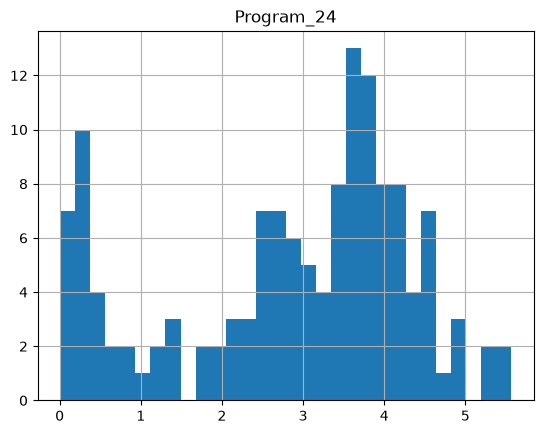

In [10]:
top = program_var.index[0]

patient_programs[top].hist(bins=30)

plt.title(top)
plt.show()

In [11]:
program_df["program"].value_counts().describe()

count     144.000000
mean       24.229167
std       123.370028
min         1.000000
25%         1.000000
50%         4.000000
75%         9.000000
max      1424.000000
Name: count, dtype: float64